In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data

# If that didn't work try using the local host URL as shown in the video

In [2]:
type(data)

dict

In [3]:
import pandas as pd


#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
#This normalizes the data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.001308e+07,2.001308e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12596,1,2026-04-08T14:27:00.000Z,None,NaN,NaN,NaN,1.430916e+12,"[mineable, pow, sha-256, store-of-value, state...",71499.053332,5.312505e+10,5.302889e+10,9.615791e+07,56.5314,-1.424514,4.987378,4.497882,3.510232,3.676347,-20.068589,1.430916e+12,58.7248,1.501480e+12,None,2026-04-08T14:27:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 16:29:27.569162
1,1027,Ethereum,ETH,ethereum,True,1.206912e+08,1.206912e+08,NaN,2015-08-07T00:00:00.000Z,11722,2,2026-04-08T14:27:00.000Z,None,NaN,NaN,NaN,2.688316e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2227.434163,2.667512e+10,2.650944e+10,1.656824e+08,57.2742,-1.426882,7.316822,4.960184,10.327830,9.036479,-27.529711,2.688316e+11,11.0394,2.688316e+11,None,2026-04-08T14:27:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 16:29:27.569162
2,825,Tether USDt,USDT,tether,True,1.841515e+11,1.889176e+11,NaN,2015-02-25T00:00:00.000Z,176874,3,2026-04-08T14:27:00.000Z,None,NaN,NaN,NaN,1.888775e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999788,1.028234e+11,1.008331e+11,1.990260e+09,46.9337,-0.013525,-0.004010,0.019127,-0.021998,0.078536,0.109590,1.841124e+11,7.5604,1.888775e+11,None,2026-04-08T14:27:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-08 16:29:27.569162
3,52,XRP,XRP,xrp,False,6.140553e+10,9.998569e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1821,4,2026-04-08T14:27:00.000Z,None,NaN,NaN,NaN,1.368068e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.368263,3.074881e+09,3.072160e+09,2.720826e+06,87.9688,-1.190836,4.923083,1.132218,0.145933,-2.626954,-34.039037,8.401894e+10,3.4483,1.368263e+11,None,2026-04-08T14:27:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 16:29:27.569162
4,1839,BNB,BNB,bnb,False,1.363567e+08,1.363567e+08,1.363567e+08,2017-07-25T00:00:00.000Z,3177,5,2026-04-08T14:27:00.000Z,None,NaN,NaN,NaN,8.277041e+10,"[marketplace, centralized-exchange, payments, ...",607.013728,2.299343e+09,2.281684e+09,1.765922e+07,44.4871,-0.970326,1.845206,-0.902366,-4.670891,-4.908090,-31.020241,8.277041e+10,3.3971,8.277041e+10,None,2026-04-08T14:27:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 16:29:27.569162
5,3408,USDC,USDC,usd-coin,False,7.820028e+10,7.820028e+10,NaN,2018-10-08T00:00:00.000Z,38562,6,2026-04-08T14:26:00.000Z,None,NaN,6.090122e+10,6.089922e+10,7.819771e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999967,1.339043e+10,1.061826e+10,2.772165e+09,17.7889,0.007832,0.007166,0.026455,-0.009995,0.024091,-0.019329,7.819771e+10,3.2092,7.819771e+10,None,2026-04-08T14:26:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-04-08 16:29:27.569162
6,5426,Solana,SOL,solana,True,5.737097e+08,6.239910e+08,NaN,2020-04-10T00:00:00.000Z,1114,7,2026-04-08T14:27:00.000Z,None,NaN,5.252369e+08,4.385939e+10,5.210575e+10,"[pos, platform, solana-ecosystem, cms-holdings...",83.504009,6.205789e+09,6.205744e+09,4.526635e+04,80.1807,-1.367187,5.717383,0.546277,-1.907194,-3.243003,-37.588201,4.790706e+10,1.9662,5.210575e+10,None,2026-04-08T14:27:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 16:29:27.569162
7,1958,TRON,TRX,tron,True,9.476928e+10,9.476928e+10,NaN,2017-09-13T00:00:00.000Z,1319,8,2026-04-08T14:28:00.000Z,None,NaN,9.466

In [5]:
def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    #Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }

    session = Session()
    session.headers.update(headers)

    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)

#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data
    
    # Use this if you just want to keep it in a dataframe
    df2 = pd.json_normalize(data['data'])
    df2['Timestamp'] = pd.to_datetime('now')
    df #= pd.concat([df, df2], ignore_index=True)

    # Use this if you want to create a csv and append data to it
    #df = pd.json_normalize(data['data'])
    #df['timestamp'] = pd.to_datetime('now')
    #df


import os 

if not os.path.isfile('API.csv'):
    df.to_csv('API.csv', header=True, index=False)
else:  
    df.to_csv('API.csv', mode='a', header=False, index=False) # Idented INSIDE else    
    #Then to read in the file: df = pd.read_csv(r'C:\Users\alexf\OneDrive\Documents\Python Scripts\API.csv')


# If that didn't work try using the local host URL as shown in the video


In [6]:
import os 
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed')
    sleep(60) #sleep for 1 minute
    # exit()

API Runner completed
API Runner completed
API Runner completed
API Runner completed
API Runner completed


KeyboardInterrupt: 

In [7]:
df = pd.read_csv('API.csv')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.001304e+07,2.001304e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12596,1,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,1.435715e+12,"['mineable', 'pow', 'sha-256', 'store-of-value...",71738.992048,4.981874e+10,4.972527e+10,9.346566e+07,48.6188,0.165142,4.885294,4.734998,5.364464,3.434171,-20.124242,1.435715e+12,58.7198,1.506519e+12,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
1,1027,Ethereum,ETH,ethereum,True,1.206912e+08,1.206912e+08,NaN,2015-08-07T00:00:00.000Z,11722,2,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,2.712609e+11,"['pos', 'smart-contracts', 'ethereum-ecosystem...",2247.562135,2.577642e+10,2.561388e+10,1.625379e+08,52.4287,-0.161005,7.806866,5.443235,12.096666,9.304856,-27.539405,2.712609e+11,11.0944,2.712609e+11,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
2,825,Tether USDt,USDT,tether,True,1.841515e+11,1.889176e+11,NaN,2015-02-25T00:00:00.000Z,176868,3,2026-04-08T12:27:00.000Z,NaN,NaN,NaN,NaN,1.889180e+11,"['stablecoin', 'asset-backed-stablecoin', 'usd...",1.000002,9.828361e+10,9.632125e+10,1.962363e+09,42.2200,0.016607,0.011066,0.045638,0.008540,0.099657,0.132462,1.841519e+11,7.5302,1.889180e+11,NaN,2026-04-08T12:27:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-08 14:35:10.937435,NaN
3,52,XRP,XRP,xrp,False,6.140553e+10,9.998569e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1821,4,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,1.376797e+11,"['medium-of-exchange', 'enterprise-solutions',...",1.376994,2.956292e+09,2.953195e+09,3.097193e+06,83.4882,-0.249499,5.359211,1.795437,1.722694,-3.123333,-33.869911,8.455507e+10,3.4588,1.376994e+11,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
4,1839,BNB,BNB,bnb,False,1.363567e+08,1.363567e+08,1.363567e+08,2017-07-25T00:00:00.000Z,3177,5,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,8.349770e+10,"['marketplace', 'centralized-exchange', 'payme...",612.347379,2.173773e+09,2.155934e+09,1.783880e+07,39.7802,-0.021517,2.689306,-0.360630,-2.674724,-4.618793,-30.715707,8.349770e+10,3.4156,8.349770e+10,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
5,3408,USDC,USDC,usd-coin,False,7.792430e+10,7.792430e+10,NaN,2018-10-08T00:00:00.000Z,38560,6,2026-04-08T12:28:00.000Z,NaN,NaN,6.090122e+10,6.088899e+10,7.790865e+10,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.999799,1.291679e+10,1.019020e+10,2.726586e+09,14.7488,-0.000548,-0.014208,0.002613,-0.036488,-0.030097,-0.004753,7.790865e+10,3.1864,7.790865e+10,NaN,2026-04-08T12:28:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-04-08 14:35:10.937435,NaN
6,5426,Solana,SOL,solana,True,5.737097e+08,6.239911e+08,NaN,2020-04-10T00:00:00.000Z,1114,7,2026-04-08T12:28:00.000Z,NaN,NaN,5.252369e+08,4.427860e+10,5.260379e+10,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",84.302143,6.000013e+09,5.999971e+09,4.205857e+04,79.5637,-0.371664,6.575597,1.088077,0.803670,-2.160087,-37.161435,4.836496e+10,1.9784,5.260379e+10,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
7,1958,TRON,TRX,tron,True,9.476943e+10,9.476943e+10,NaN,2017-09-13T00:00:00.000Z,1319,8,2026-04-08T12:29:

In [8]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [9]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,False,20013040.00000,20013040.00000,21000000.00000,2010-07-13T00:00:00.000Z,12596,1,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,1435715317415.90991,"['mineable', 'pow', 'sha-256', 'store-of-value...",71738.99205,49818740246.43270,49725274590.91125,93465655.52146,48.61880,0.16514,4.88529,4.73500,5.36446,3.43417,-20.12424,1435715317415.90991,58.71980,1506518833007.59009,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
1,1027,Ethereum,ETH,ethereum,True,120691160.37324,120691160.37324,NaN,2015-08-07T00:00:00.000Z,11722,2,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,271260882030.45999,"['pos', 'smart-contracts', 'ethereum-ecosystem...",2247.56213,25776421065.33705,25613883135.61264,162537929.72441,52.42870,-0.16101,7.80687,5.44324,12.09667,9.30486,-27.53940,271260882030.45999,11.09440,271260882030.45999,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
2,825,Tether USDt,USDT,tether,True,184151480311.99927,188917624595.19785,NaN,2015-02-25T00:00:00.000Z,176868,3,2026-04-08T12:27:00.000Z,NaN,NaN,NaN,NaN,188918014667.26001,"['stablecoin', 'asset-backed-stablecoin', 'usd...",1.00000,98283609839.09540,96321246429.66296,1962363409.43221,42.22000,0.01661,0.01107,0.04564,0.00854,0.09966,0.13246,184151860543.04999,7.53020,188918014667.26001,NaN,2026-04-08T12:27:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-08 14:35:10.937435,NaN
3,52,XRP,XRP,xrp,False,61405531717.00000,99985687636.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1821,4,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,137679727067.69000,"['medium-of-exchange', 'enterprise-solutions',...",1.37699,2956291778.36850,2953194584.97705,3097193.39144,83.48820,-0.24950,5.35921,1.79544,1.72269,-3.12333,-33.86991,84555070301.87000,3.45880,137699435112.07001,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
4,1839,BNB,BNB,bnb,False,136356747.48000,136356747.48000,136356749.11000,2017-07-25T00:00:00.000Z,3177,5,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,83497696932.50000,"['marketplace', 'centralized-exchange', 'payme...",612.34738,2173772634.32342,2155933838.52712,17838795.79629,39.78020,-0.02152,2.68931,-0.36063,-2.67472,-4.61879,-30.71571,83497696932.50000,3.41560,83497697930.63000,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
5,3408,USDC,USDC,usd-coin,False,77924298913.68858,77924298913.68858,NaN,2018-10-08T00:00:00.000Z,38560,6,2026-04-08T12:28:00.000Z,NaN,NaN,60901219650.23000,60888992013.63738,77908653414.07001,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.99980,12916789732.03440,10190203545.42031,2726586186.61408,14.74880,-0.00055,-0.01421,0.00261,-0.03649,-0.03010,-0.00475,77908653414.07001,3.18640,77908653414.07001,NaN,2026-04-08T12:28:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-04-08 14:35:10.937435,NaN
6,5426,Solana,SOL,solana,True,573709749.64759,623991087.76785,NaN,2020-04-10T00:00:00.000Z,1114,7,2026-04-08T12:28:00.000Z,NaN,NaN,525236893.30000,44278595806.46789,52603786052.65000,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",84.30214,6000013361.62456,5999971303.05073,42058.57383,79.56370,-0.37166,6.57560,1.08808,0.

In [10]:
df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.41634,5.35340,5.43028,5.58601,4.44386,-19.81655
Ethereum,0.24000,8.14276,6.05679,12.49532,10.44052,-27.10396
Tether USDt,0.00241,0.00924,0.03884,-0.00393,0.08005,0.12160
XRP,0.23805,5.68908,2.04075,1.93989,-2.53090,-33.47810
BNB,0.13499,2.65558,-0.19963,-2.87585,-3.98326,-30.54904
USDC,-0.00404,-0.00018,0.00710,-0.02538,-0.00589,0.00676
Solana,0.03494,6.90450,1.81300,0.50892,-1.95481,-36.91053
TRON,0.00646,1.11379,0.78503,11.48493,15.51993,7.41042
Dogecoin,0.08442,4.22474,1.88337,3.84185,-2.39012,-32.32413


In [11]:
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h      0.41634
              quote.USD.percent_change_24h     5.35340
              quote.USD.percent_change_7d      5.43028
              quote.USD.percent_change_30d     5.58601
              quote.USD.percent_change_60d     4.44386
              quote.USD.percent_change_90d   -19.81655
Ethereum      quote.USD.percent_change_1h      0.24000
              quote.USD.percent_change_24h     8.14276
              quote.USD.percent_change_7d      6.05679
              quote.USD.percent_change_30d    12.49532
              quote.USD.percent_change_60d    10.44052
              quote.USD.percent_change_90d   -27.10396
Tether USDt   quote.USD.percent_change_1h      0.00241
              quote.USD.percent_change_24h     0.00924
              quote.USD.percent_change_7d      0.03884
              quote.USD.percent_change_30d    -0.00393
              quote.USD.percent_change_60d     0.08005
              quote.US

In [12]:
type(df4)

pandas.core.series.Series

In [13]:
df5 = df4.to_frame(name='values')
df5

values
name                                               
Bitcoin      quote.USD.percent_change_1h    0.41634
             quote.USD.percent_change_24h   5.35340
             quote.USD.percent_change_7d    5.43028
             quote.USD.percent_change_30d   5.58601
             quote.USD.percent_change_60d   4.44386
             quote.USD.percent_change_90d -19.81655
Ethereum     quote.USD.percent_change_1h    0.24000
             quote.USD.percent_change_24h   8.14276
             quote.USD.percent_change_7d    6.05679
             quote.USD.percent_change_30d  12.49532
             quote.USD.percent_change_60d  10.44052
             quote.USD.percent_change_90d -27.10396
Tether USDt  quote.USD.percent_change_1h    0.00241
             quote.USD.percent_change_24h   0.00924
             quote.USD.percent_change_7d    0.03884
             quote.USD.percent_change_30d  -0.00393
             quote.USD.percent_change_60d   0.08005
             quote.USD.percent_change_90d   0.12160
XRP          quote.USD.percent_change_1h    0.23805
             quote.USD.percent_change_24h   5.68908
             quote.USD.percent_change_7d    2.04075
             quote.USD.percent_change_30d   1.93989
             quote.USD.percent_change_60d  -2.53090
             quote.USD.percent_change_90d -33.47810
BNB          quote.USD.percent_change_1h    0.13499
             quote.USD.percent_change_24h   2.65558
             quote.USD.percent_change_7d   -0.19963
             quote.USD.percent_change_30d  -2.87585
             quote.USD.percent_change_60d  -3.98326
             quote.USD.percent_change_90d -30.54904
USDC         quote.USD.percent_change_1h   -0.00404
             quote.USD.percent_change_24h  -0.00018
             quote.USD.percent_change_7d    0.00710
             quote.USD.percent_change_30d  -0.02538
             quote.USD.percent_change_60d  -0.00589
             quote.USD.percent_change_90d   0.00676
Solana       quote.USD.percent_change_1h    0.03494
             quote.USD.percent_change_24h   6.90450
             quote.USD.percent_change_7d    1.81300
             quote.USD.percent_change_30d   0.50892
             quote.USD.percent_change_60d  -1.95481
             quote.USD.percent_change_90d -36.91053
TRON         quote.USD.percent_change_1h    0.00646
             quote.USD.percent_change_24h   1.11379
             quote.USD.percent_change_7d    0.78503
             quote.USD.percent_change_30d  11.48493
             quote.USD.percent_change_60d  15.51993
             quote.USD.percent_change_90d   7.41042
Dogecoin     quote.USD.percent_change_1h    0.08442
             quote.USD.percent_change_24h   4.22474
             quote.USD.percent_change_7d    1.88337
             quote.USD.percent_change_30d   3.84185
             quote.USD.percent_change_60d  -2.39012
             quote.USD.percent_change_90d -32.32413
Hyperliquid  quote.USD.percent_change_1h    0.79293
             quote.USD.percent_change_24h   9.76466
             quote.USD.percent_change_7d    6.94018
             quote.USD.percent_change_30d  23.93749
             quote.USD.percent_change_60d  20.68834
             quote.USD.percent_change_90d  52.68482
UNUS SED LEO quote.USD.percent_change_1h   -0.06126
             quote.USD.percent_change_24h  -0.08851
             quote.USD.percent_change_7d    0.85655
             quote.USD.percent_change_30d  11.63024
             quote.USD.percent_change_60d  29.66282
             quote.USD.percent_change_90d  12.25528
Cardano      quote.USD.percent_change_1h   -0.14805
             quote.USD.percent_change_24h   6.28613
             quote.USD.percent_change_7d    3.69646
             quote.USD.percent_change_30d   0.60897
             quote.USD.percent_change_60d  -5.25242
             quote.USD.percent_change_90d -33.65835
Bitcoin Cash quote.USD.percent_change_1h    0.58227
             quote.USD.percent_change_24h   3.71550
             quote.USD.percent_change_7d   -2.42492
             quote.USD.percent_change_30d

In [16]:
df5.count()

values    90
dtype: int64

In [19]:
index = pd.Index(range(90))

df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.41634
1,Bitcoin,quote.USD.percent_change_24h,5.35340
2,Bitcoin,quote.USD.percent_change_7d,5.43028
3,Bitcoin,quote.USD.percent_change_30d,5.58601
4,Bitcoin,quote.USD.percent_change_60d,4.44386
5,Bitcoin,quote.USD.percent_change_90d,-19.81655
6,Ethereum,quote.USD.percent_change_1h,0.24000
7,Ethereum,quote.USD.percent_change_24h,8.14276
8,Ethereum,quote.USD.percent_change_7d,6.05679
9,Ethereum,quote.USD.percent_change_30d,12.49532


In [20]:
df7 = df6.rename(columns={'level_1': 'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,0.41634
1,Bitcoin,quote.USD.percent_change_24h,5.35340
2,Bitcoin,quote.USD.percent_change_7d,5.43028
3,Bitcoin,quote.USD.percent_change_30d,5.58601
4,Bitcoin,quote.USD.percent_change_60d,4.44386
5,Bitcoin,quote.USD.percent_change_90d,-19.81655
6,Ethereum,quote.USD.percent_change_1h,0.24000
7,Ethereum,quote.USD.percent_change_24h,8.14276
8,Ethereum,quote.USD.percent_change_7d,6.05679
9,Ethereum,quote.USD.percent_change_30d,12.49532


In [25]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,0.41634
1,Bitcoin,24h,5.35340
2,Bitcoin,7d,5.43028
3,Bitcoin,30d,5.58601
4,Bitcoin,60d,4.44386
5,Bitcoin,90d,-19.81655
6,Ethereum,quote.USD.percent_change_1h,0.24000
7,Ethereum,24h,8.14276
8,Ethereum,7d,6.05679
9,Ethereum,30d,12.49532


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

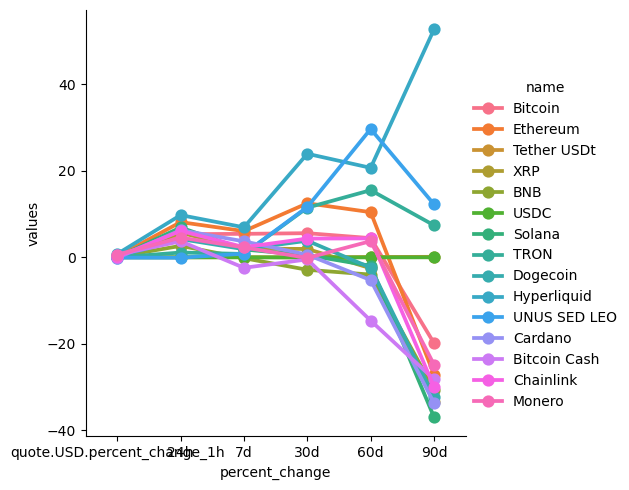

In [28]:
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')

In [29]:
df10 = df[['name','quote.USD.price','timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,71738.99205,2026-04-08 14:35:10.937435
15,Bitcoin,71965.75076,NaN
30,Bitcoin,71965.75076,NaN
45,Bitcoin,71963.30734,NaN
60,Bitcoin,71973.85849,NaN
75,Bitcoin,71972.39324,NaN
90,Bitcoin,72042.12161,NaN
105,Bitcoin,72078.86106,NaN
120,Bitcoin,72078.86106,NaN
135,Bitcoin,72072.58630,NaN


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

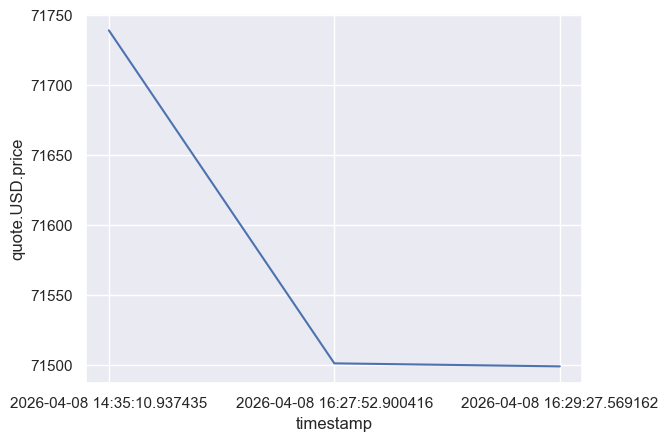

In [30]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='timestamp', y='quote.USD.price', data = df10)

In [33]:
df.drop_duplicates(inplace=True)

df.isnull().sum()

df.ffill(inplace=True)

In [34]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,False,20013040.00000,20013040.00000,21000000.00000,2010-07-13T00:00:00.000Z,12596,1,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,1435715317415.90991,"['mineable', 'pow', 'sha-256', 'store-of-value...",71738.99205,49818740246.43270,49725274590.91125,93465655.52146,48.61880,0.16514,4.88529,4.73500,5.36446,3.43417,-20.12424,1435715317415.90991,58.71980,1506518833007.59009,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
1,1027,Ethereum,ETH,ethereum,True,120691160.37324,120691160.37324,21000000.00000,2015-08-07T00:00:00.000Z,11722,2,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,271260882030.45999,"['pos', 'smart-contracts', 'ethereum-ecosystem...",2247.56213,25776421065.33705,25613883135.61264,162537929.72441,52.42870,-0.16101,7.80687,5.44324,12.09667,9.30486,-27.53940,271260882030.45999,11.09440,271260882030.45999,NaN,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-04-08 14:35:10.937435,NaN
2,825,Tether USDt,USDT,tether,True,184151480311.99927,188917624595.19785,21000000.00000,2015-02-25T00:00:00.000Z,176868,3,2026-04-08T12:27:00.000Z,NaN,NaN,NaN,NaN,188918014667.26001,"['stablecoin', 'asset-backed-stablecoin', 'usd...",1.00000,98283609839.09540,96321246429.66296,1962363409.43221,42.22000,0.01661,0.01107,0.04564,0.00854,0.09966,0.13246,184151860543.04999,7.53020,188918014667.26001,NaN,2026-04-08T12:27:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-08 14:35:10.937435,NaN
3,52,XRP,XRP,xrp,False,61405531717.00000,99985687636.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1821,4,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,137679727067.69000,"['medium-of-exchange', 'enterprise-solutions',...",1.37699,2956291778.36850,2953194584.97705,3097193.39144,83.48820,-0.24950,5.35921,1.79544,1.72269,-3.12333,-33.86991,84555070301.87000,3.45880,137699435112.07001,NaN,2026-04-08T12:28:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-08 14:35:10.937435,NaN
4,1839,BNB,BNB,bnb,False,136356747.48000,136356747.48000,136356749.11000,2017-07-25T00:00:00.000Z,3177,5,2026-04-08T12:28:00.000Z,NaN,NaN,NaN,NaN,83497696932.50000,"['marketplace', 'centralized-exchange', 'payme...",612.34738,2173772634.32342,2155933838.52712,17838795.79629,39.78020,-0.02152,2.68931,-0.36063,-2.67472,-4.61879,-30.71571,83497696932.50000,3.41560,83497697930.63000,NaN,2026-04-08T12:28:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-04-08 14:35:10.937435,NaN
5,3408,USDC,USDC,usd-coin,False,77924298913.68858,77924298913.68858,136356749.11000,2018-10-08T00:00:00.000Z,38560,6,2026-04-08T12:28:00.000Z,NaN,NaN,60901219650.23000,60888992013.63738,77908653414.07001,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.99980,12916789732.03440,10190203545.42031,2726586186.61408,14.74880,-0.00055,-0.01421,0.00261,-0.03649,-0.03010,-0.00475,77908653414.07001,3.18640,77908653414.07001,NaN,2026-04-08T12:28:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-04-08 14:35:10.937435,NaN
6,5426,Solana,SOL,solana,True,573709749.64759,623991087.76785,136356749.11000,2020-04-10T00:00:00.000Z,1114,7,2026-04-08T12:28:00.000Z,NaN,NaN,525236893.30000,44278595806.46789,526

In [35]:
import matplotlib.pyplot as plt

df.describe()

df.corr(numeric_only=True)



,id,infinite_supply,circulating_supply,total_supply,max_supply,num_market_pairs,cmc_rank,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,platform.id
id,1.00000,-0.23087,-0.23417,-0.24714,-0.14039,-0.12640,0.15860,NaN,NaN,-0.46436,0.00834,-0.16015,-0.13544,-0.18563,-0.18689,-0.05660,0.23058,0.21222,0.44970,0.46141,0.71437,0.44347,0.76560,-0.17353,-0.17352,-0.15880,NaN,0.95503
infinite_supply,-0.23087,1.00000,0.43965,0.38926,-0.30390,0.28293,-0.12599,NaN,NaN,0.33202,0.19892,-0.15043,-0.21012,0.26639,0.27014,0.01785,0.16785,-0.05596,-0.03864,0.01201,-0.01731,0.02665,-0.13532,-0.13859,-0.13859,-0.15396,NaN,-0.22483
circulating_supply,-0.23417,0.43965,1.00000,0.98865,0.06000,0.63178,-0.25231,NaN,NaN,0.63242,0.27772,-0.13663,-0.19188,0.46416,0.45651,0.49312,0.18545,-0.15704,-0.46547,-0.28038,-0.17380,-0.16503,0.06015,-0.13690,-0.13690,-0.13903,NaN,-0.17936
total_supply,-0.24714,0.38926,0.98865,1.00000,0.20465,0.61075,-0.27761,NaN,NaN,0.60668,0.23653,-0.13827,-0.20109,0.44304,0.43590,0.46521,0.22945,-0.15667,-0.43005,-0.26871,-0.19208,-0.19155,0.02467,-0.14380,-0.14381,-0.14102,NaN,-0.18394
max_supply,-0.14039,-0.30390,0.06000,0.20465,1.00000,-0.13205,-0.11391,NaN,NaN,-0.02927,-0.21957,-0.06919,-0.10733,-0.16442,-0.16222,-0.15798,0.33817,-0.06145,0.18663,0.06493,-0.16311,-0.22016,-0.26821,-0.10094,-0.10095,-0.07086,NaN,-0.07285
num_market_pairs,-0.12640,0.28293,0.63178,0.61075,-0.13205,1.00000,-0.39010,NaN,NaN,0.03244,-0.01342,0.07822,-0.02969,0.89384,0.88663,0.70440,-0.14748,-0.07957,-0.44031,-0.22201,-0.21283,-0.11239,0.18228,0.08076,0.08076,0.07321,NaN,-0.10456
cmc_rank,0.15860,-0.12599,-0.25231,-0.27761,-0.11391,-0.39010,1.00000,NaN,NaN,-0.07844,-0.11521,-0.58788,-0.44361,-0.60804,-0.60793,-0.32315,-0.04599,0.06794,0.05744,-0.20789,-0.00439,0.02620,0.02965,-0.57863,-0.57863,-0.58096,NaN,0.12850
tvl_ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_reported_circulating_supply,-0.46436,0.33202,0.63242,0.60668,-0.02927,0.03244,-0.07844,NaN,NaN,1.00000,0.27407,-0.02350,-0.01814,-0.01357,-0.01866,0.15609,0.02588,-0.10207,-0.35492,-0.25835,-0.20490,-0.25367,-0.21194,-0.01352,-0.01352,-0.02325,NaN,-0.37953


ValueError: Could not interpret value `price` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>